# **California Prescribed Fire Monitoring — Building Skills from an NDP Catalog**

The [Observed Field Data for UC Climate Action Seed Project](https://nationaldataplatform.org/dataset/observed-field-data-for-uc-climate-action
-seed-project-scaling-science-driven-vegetation-treatm)
dataset on the **National Data Platform** records field observations
from the **"burn3d"** research program — a joint effort between the
University of California and California's Prescribed Fire Monitoring
Program to quantify how vegetation-treatment prescribed burns affect
Central Valley and Sierra Nevada ecosystems. Field teams re-visit
six California sites both **before and after** prescribed fires,
recording tree inventories, downed woody fuel loads, ground and
vegetation cover, and post-fire regeneration across permanent plots.

The dataset ships as 20 relational CSV tables (~1.2 MiB total)
linked by an `inventory_id` foreign key. The `%%skill-build` cell
below runs a **two-skill chain**: ARGUS's `ndp-skill-builder`
translates the catalog URL to the CKAN API endpoint under the hood,
delegates the download to the standard CKAN fetcher, and hands off
to `tabular-skill-builder` which groups the 20 tables into five
thematic skills by domain — plots (spatial), trees, downed woody
fuels, ground / vegetation cover, and post-fire regeneration. The
`%%ask` reply in the next cell confirms the plan and kicks off the
build.


####   **Choose your language model**

Argus is model-agnostic — you can plug in any major LLM provider that offers a strong code-generation model. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

**This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users). If you don't have NRP access, swap in another provider — they all work the same way.

**Before you run the cell: save your API key as a Colab Secret**

Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the notebook with.

1. Click the 🔑 key icon in the left sidebar (**Secrets**).
2. Click **+ Add new secret**.
3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
   - `NRP_API_KEY` for NRP-served models
   - `OPENAI_API_KEY` for OpenAI
   - `ANTHROPIC_API_KEY` for Anthropic
   - `GOOGLE_API_KEY` for Google
   - `ZAI_API_KEY` for Z.ai
4. Paste your key into the **Value** field.
5. Toggle **Notebook access** on for this notebook.

If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

### Choosing a model

Argus generates and runs Python against real data on every turn. The model must be **excellent at coding** — not just capable of tool-calling. Chat-tuned models with strong conversational performance but weaker code generation produce Argus runs that fail on real datasets, retry many times, or drift into wordy exploration without converging.

**What to pick**: choose your provider's top-tier code-focused model — the one they market for agentic coding, software engineering, or long-context multi-step work. Avoid the chat-tuned default.

**Known quirks**: heavily-quantized model variants (4-bit weights or smaller) can complete workflows but with excess retries and lower-quality code. If you have the choice between quantized and full-precision for the same model, pick full-precision.

In [1]:
# Use GLM-5 from National Research Platform
# LLM = {
#     "model": "glm-5",
#     "url": "https://ellm.nrp-nautilus.io/v1",
#     "api_key_env": "NRP_API_KEY",
# }

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
LLM = {
    "model": "glm-5",
    "url": "https://api.z.ai/api/coding/paas/v4",
    "api_key_env": "ZAI_API_KEY",
}

#### **Install Argus from GitHub Repo**

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 13 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, ckan-skill-builder, ndp-search, ndp-skill-builder, repo-skill-builder, s3-skill-builder, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, tabular-skill-builder, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [ ]:
%reset

In [3]:
%%skill-build
https://nationaldataplatform.org/dataset/observed-field-data-for-uc-climate-action-seed-project-scaling-science-driven-vegetation-treatm

The URL is from `nationaldataplatform.org/dataset/...`, which matches the `ndp-skill-builder` meta-skill (not ArcGIS, since the path contains `/dataset/` not `/FeatureServer`/`/MapServer`). Let me read its instructions.

The URL matches `ndp-skill-builder` (nationaldataplatform.org `/dataset/` form). Let me set up my task tracking and locate the bundled `fetch.py` and the downstream `tabular-skill-builder` skill.

Both bundled scripts exist. The slug from the URL is `observed-field-data-for-uc-climate-action-seed-project-scaling-science-driven-vegetation-treatm`. Let me run `fetch.py` to download the dataset.

Timeout overrides aren't supported. Let me retry without the timeout parameter.

Downloaded 20 CSV resources successfully. Now I'll read `tabular-skill-builder`'s SKILL.md and run its inventory script on the download directory.

I've inspected the inventory. This is a relational field-data dataset: 18 distinct measurement tables (plus 2 documentation files), all linked by `inventory_id`, each with a different schema and grain. Let me update my tracking and present the proposal at the Step 4 hard gate.

I've inspected the downloaded NDP dataset. Here's what I found and what I propose.

**Source** : `https://nationaldataplatform.org/dataset/observed-field-data-for-uc-climate-action-seed-project-scaling-science-driven-vegetation-treatm` — *"Observed Field Data for UC Climate Action Seed Project: Scaling Science-Driven Vegetation Treatments for a Wildfire Resilient California"*
**Files scanned** : 20 CSV files (no other formats). The files fall into three kinds:

| Kind | Files | Notes |
|------|-------|-------|
| **Documentation** | `SchemaSummary.csv`, `column_descriptions.csv` | Reference-only; will feed the SKILL.md fields table, not become a queryable skill |
| **Anchor table** | `01_plot_identification.csv` (163 rows, 61 cols) | The parent `inventory_id` registry — plot/site metadata every other table joins to |
| **Measurement tables** | `02`–`18` (18 files) | Each keyed by `inventory_id` (and nested child ids), each a distinct grain/entity |

Every measurement table shares `inventory_id` as the join key back to the plot-identification anchor. The schemas are all **distinct** (18 separate groups) — these are genuinely different entities (trees, fuels, regeneration seedlings, coarse woody debris, etc.), not near-matches, so each becomes its own skill and there are no merge-reconciliation questions.

**Proposed skills** (one per measurement entity, 19 skills total — `01` anchor + 18 measurement tables). I've named them for the entity each row represents:

1. **`veg-treatment-plots`** — each row is a **field plot / site inventory** (the anchor table)
   - From: `01_plot_identification.csv` (163 rows, 61 cols)
   - Key cols: `inventory_id`, `site_project`, `site_name`, `plot_num`, `inventory_pre_post_fire`

2. **`veg-treatment-inventory-observations`** — each row is an **inventory observation record**
   - From: `02_inventory_obs.csv` (436 rows, 3 cols)
   - Key cols: `inventory_id`, `inventory_obs`, `inventory_obs_label`

3. **`veg-treatment-tree-inventory`** — each row is an **individual tree**
   - From: `03_tree.csv` (2,147 rows, 22 cols)
   - Key cols: `inventory_id`, `tree_id`, `tree_tag`, `tree_sp`, `tree_status`

4. **`veg-treatment-basal-area`** — each row is a **basal-area tally entry**
   - From: `04_basalarea.csv` (390 rows, 10 cols)
   - Key cols: `inventory_id`, `ba_id`, `ba_sp`, `ba_status`, `ba_baf`

5. **`veg-treatment-fuels`** — each row is a **fuel-loading transect observation**
   - From: `05_fuels.csv` (570 rows, 20 cols)
   - Key cols: `inventory_id`, `fuels_id`, `fuels_azimuth`, `fuels_slope_percent`, `fuels_x1h_length_m`

6. **`veg-treatment-burn-piles`** — each row is a **burn pile**
   - From: `06_burn_pile.csv` (58 rows, 12 cols)
   - Key cols: `inventory_id`, `burn_pile_id`, `burn_pile_height_max`, `burn_pile_diam_max`

7. **`veg-treatment-clip-plots`** — each row is a **clip-plot (herbaceous clip) setup**
   - From: `07_clip_plot.csv` (306 rows, 11 cols)
   - Key cols: `inventory_id`, `clip_plot_id`, `clip_plot_type`, `clip_plot_distance`

8. **`veg-treatment-ground-cover`** — each row is a **ground-cover classification**
   - From: `08_ground_cover_tr.csv` (134 rows, 4 cols)
   - Key cols: `inventory_id`, `ground_cover_id`, `ground_cover_tr`

9. **`veg-treatment-tree-health`** — each row is a **tree health rating**
   - From: `09_tree_health.csv` (486 rows, 4 cols)
   - Key cols: `inventory_id`, `tree_id`, `tree_health`

10. **`veg-treatment-vegetation-cover`** — each row is a **vegetation-cover classification**
    - From: `10_veg_cover_tr.csv` (117 rows, 4 cols)
    - Key cols: `inventory_id`, `veg_cover_id`, `veg_cover_tr`

11. **`veg-treatment-regeneration-observations`** — each row is a **regeneration observation record**
    - From: `11_reg_obs.csv` (254 rows, 4 cols)
    - Key cols: `inventory_id`, `reg_id`, `reg_obs`

12. **`veg-treatment-regeneration-seedlings`** — each row is a **regeneration seedling (tse)**
    - From: `12_regen_tse.csv` (510 rows, 13 cols)
    - Key cols: `inventory_id`, `reg_id`, `reg_tse_id`, `reg_tse_sp`, `reg_tse_status`

13. **`veg-treatment-regeneration-saplings`** — each row is a **regeneration sapling (tsa)**
    - From: `13_regen_tsa.csv` (163 rows, 12 cols)
    - Key cols: `inventory_id`, `reg_id`, `reg_tsa_id`, `reg_tsa_sp`, `reg_tsa_status`

14. **`veg-treatment-regeneration-sprouts`** — each row is a **regeneration sprouted tree (tre)**
    - From: `14_regen_tre.csv` (54 rows, 11 cols)
    - Key cols: `inventory_id`, `reg_id`, `reg_tre_id`, `reg_tre_sp`, `reg_tre_status`

15. **`veg-treatment-species-cover`** — each row is a **species cover observation**
    - From: `15_species_cover.csv` (2,327 rows, 16 cols)
    - Key cols: `inventory_id`, `sp_invcov_id`, `sp_cov_sp`, `sp_cov_status`

16. **`veg-treatment-coarse-woody-debris`** — each row is a **coarse woody debris piece**
    - From: `16_cwd.csv` (876 rows, 12 cols)
    - Key cols: `inventory_id`, `fuels_id`, `cwd_id`, `cwd_sp`, `cwd_diam`

17. **`veg-treatment-clip-plot-fuels`** — each row is a **clip-plot fuel sample**
    - From: `17_clip_plot_fuel.csv` (381 rows, 7 cols)
    - Key cols: `inventory_id`, `clip_plot_id`, `clip_plot_fuel_id`, `clip_plot_fuel_strata`

18. **`veg-treatment-clip-plot-fuel-types`** — each row is a **clip-plot fuel-type entry**
    - From: `18_clip_plot_fuel_fuel.csv` (1,687 rows, 5 cols)
    - Key cols: `inventory_id`, `clip_plot_id`, `clip_plot_fuel_id`, `clip_plot_fuel_fuel`

**Design notes (no action needed unless you disagree):**
- `SchemaSummary.csv` and `column_descriptions.csv` are **not** becoming skills — they're documentation. I'll mine them for each SKILL.md's `
## Fields` table so the generated skills carry human-readable column definitions.
- Each skill's Parquet keeps the `inventory_id` join key so tables can be related back to the `veg-treatment-plots` anchor.
- These are tabular skills (no geometry columns detected), so output is `.parquet` per skill.

**Open questions (please confirm):**

1. **Skill count** — 19 skills is a lot for one dataset. Would you prefer fewer, broader skills? Alternatives:
   - Keep all 19 (one per entity, most granular) — *my recommendation.*
   - Consolidate the 3 regeneration tables (seedlings/saplings/sprouts, skills 12–14) into a single `veg-treatment-regeneration` skill with a `regeneration_class` discriminator column.
   - Consolidate the 3 clip-plot tables (skills 7, 17, 18) into one `veg-treatment-clip-plots` skill.
2. **Skill name prefix** — I used `veg-treatment-` for all. Happy to change (e.g. `uc-climate-veg-`, `california-fuels-`).

Reply with **"yes"** to proceed as proposed (19 skills), or with edits (e.g. "consolidate regeneration into one skill", "rename the prefix to X", "drop the ground-cover one").

(Resume state on disk: `/tmp/repo-skills/observed-field-data-for-uc-climate-action-seed-project-scaling-science-driven-vegetation-treatm/` — the source files, `_inventory.json`, and `_ckan_metadata.json` are all there.)

In [4]:
%%ask
Yes, but please do your best to consolidate them as less skills as possible.

I'll consolidate the 19 tables into as few skills as possible. Let me first re-read the builder skill to understand the consolidation mechanics, and check what's on disk from the previous session.

Let me read the rest of the tabular-skill-builder skill (Steps 7-9) and verify the resume state on disk.

Resume state is intact — all 18 CSVs, `_inventory.json`, and `_ckan_metadata.json` are present. The user approved building but wants maximum consolidation. I'll group the 19 tables into 5 coherent skills.

Let me set up my task plan and write the build script.

Let me look at the inventory and CKAN metadata to get exact column names for the build script.

Now I'll write the consolidated build script. The plan: 5 skills covering all 18 measurement tables, grouped by ecological theme with discriminator columns where schemas are concat-merged.

...

All 5 skills present (SKILL.md + parquet). Now clean up the intermediate scratch files and delete the source directory.

Each skill directory now contains exactly SKILL.md + one parquet. Now verify the source directory has the `_inventory.json` marker before deleting.

Let me do a final verification that each parquet loads correctly and report row/column counts.

All five skills load cleanly. Let me do a final self-audit and update the todos.

I had several edit-and-retry cycles on `build_skills.py` during this build. Per the Learnings Protocol, I should record these lessons. The matching skill is `tabular-skill-builder`.

Built **5 skills** (down from 19 proposed), consolidating the 18 measurement tables by ecological theme. Each non-anchor skill uses a discriminator column so its source sub-tables are recoverable.

---

✓ Built skill **veg-treatment-plots** at `_skills_/veg-treatment-plots/SKILL.md`.

Each row is a **field plot inventory** — the anchor registry (163 plots, 6 sites across California, pre- and post-fire). UTM coordinates were reprojected to WGS84 lat/lon so the skill is spatially queryable. Observers from `02_inventory_obs.csv` were rolled up per inventory.

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Site | `site_name_label` | Sedgwick Reserve, Calaveras Big Trees, Shaver Lake, Independence Lake, Pacific Union College, Winton-Schaads VMP |
| Fire timing | `inventory_pre_post_fire_label` | Prefire, Postfire_imm |
| Fire severity | `inventory_firesever_label` | Unburned, Light patchy, Lightly burned, Moderately burned |
| Topography | `plot_slopeper`, `plot_aspectdegre` | slope %, aspect degrees |
| Inventory date | `inventory_date` | 9/13/24, 10/23/24, 11/9/24 |
| Crew | `inventory_observers` | Abigail, Josh, Nat, Peter, Oscar |
| Spatial area | (`lat`, `lon`) | any rectangle in WGS84 |

---

✓ Built skill **veg-treatment-trees** at `_skills_/veg-treatment-trees/SKILL.md`.

Each row is an **individual tree** (2,302 trees, 23 species). Merges the main tree inventory (`03_tree.csv`) with tree-health ratings (`09_tree_health.csv`) joined on `(inventory_id, tree_id)`. Tree tags repeat across inventories; use `(inventory_id, tree_id)` as the composite key.

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Species | `tree_sp` / `tree_sp_scientific_name` | CADE (incense cedar), ABCO (white fir), QUAG (coast live oak), PICO (lodgepole), PIJE (Jeffrey), PSME (Douglas-fir) |
| Status | `tree_status` | Live, Dead |
| Health | `tree_health_label` | dead top, pitching on bole, split top, catface, scars from heavy equipment |
| Decay class | `tree_decay_class` | 1 (sound) → 5 (powdery) |
| Size | `tree_dbh`, `tree_ht` | DBH (cm), height (m) |
| Fire effects | `treepost_scorch_m`, `treepost_torch_per`, `treepost_bole_char_m` | scorch/torch height & %, bole char height |

---

✓ Built skill **veg-treatment-regeneration** at `_skills_/veg-treatment-regeneration/SKILL.md`.

Each row is a **regeneration individual** (727 records). Consolidates three source tables into one with a `regeneration_class` discriminator:

| Class | Source | Count | Key extra fields |
|---|---|---|---|
| `seedling` | `12_regen_tse.csv` | 510 | age class (0 yr / >1 yr), count |
| `sapling` | `13_regen_tsa.csv` | 163 | DBH, cohort count |
| `sprout` | `14_regen_tre.csv` | 54 | clump count |

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Regeneration class | `regeneration_class` | seedling, sapling, sprout |
| Species | `reg_sp` / `reg_sp_scientific_name` | CADE, ABCO, NODE (tanoak), QUKE (black oak), PILA (sugar pine) |
| Status | `reg_status` | Live, Dead |
| Age (seedlings) | `reg_age` | zero (0 yr), more_1 (>1 yr) |
| Plot/site | `inventory_id` | join to `veg-treatment-plots` |

---

✓ Built skill **veg-treatment-fuels** at `_skills_/veg-treatment-fuels/SKILL.md`.

Each row is a **fuel or fuel-loading observation** (2,200 records). Consolidates five distinct measurement types with a `measurement_type` discriminator:

| Type | Source | Count | What it measures |
|---|---|---|---|
| `fuel_transect` | `05_fuels.csv` | 570 | 1h/10h/100h/1000h tallies, duff/litter/fuelbed depth |
| `coarse_woody_debris` | `16_cwd.csv` | 876 | individual CWD pieces (species, diam, decay 1–5) |
| `burn_pile` | `06_burn_pile.csv` | 58 | pile size class, dimensions, dominant species |
| `basal_area` | `04_basalarea.csv` | 390 | BAF tallies → m²/ha per species |
| `clip_plot` | `07`+`17`+`18` joined | 306 | dry fuel weight (g) by strata & fuel type |

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Measurement type | `measurement_type` | fuel_transect, coarse_woody_debris, burn_pile, basal_area, clip_plot |
| Species | `cwd_sp` / `ba_sp` / `burn_pile_sp` | ABCO, CADE, PILA, PIJE, PIPO, QUAG |
| CWD decay | `cwd_decay` | 1 (sound, elevated) → 5 (powdery, below ground) |
| Burn-pile size | `burn_pile_class` | small (<7.6 cm), large (>7.6 cm) |
| Clip-plot timing | `clip_plot_type` | Prefire, Postfire |
| Plot/site | `inventory_id` | join to `veg-treatment-plots` |

---

✓ Built skill **veg-treatment-cover** at `_skills_/veg-treatment-cover/SKILL.md`.

Each row is a **cover observation** (2,578 records). Consolidates three cover tables with a `cover_type` discriminator:

| Type | Source | Count | What it measures |
|---|---|---|---|
| `ground` | `08_ground_cover_tr.csv` | 134 | ground classes (rock, bare soil, litter, CWD, etc.) |
| `vegetation` | `10_veg_cover_tr.csv` | 117 | cover layers (overstory, understory, shrub, herb) |
| `species` | `15_species_cover.csv` | 2,327 | per-species % cover, lifeform, layer, shrub height |

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Cover type | `cover_type` | ground, vegetation, species |
| Lifeform (species) | `sp_cov_lifeform` | TR (tree), SH (shrub), FB (forb), GR (graminoid), FERN |
| Cover layer (species) | `sp_cov_layer` | TOV (overstory), TSA (sapling), TSE (seedling), TRE (resprout) |
| Ground class | `ground_cover_tr` | Rock, CWD, Bare soil, Litter, BlackLitter, Basal veg |
| Veg layer | `veg_cover_tr` | TOV, und, TOS, herb |
| Status | `sp_cov_status` | Live, Dead |
| Plot/site | `inventory_id` | join to `veg-treatment-plots` |

---

**Consolidation summary:** 18 measurement tables → 5 skills. All skills share `inventory_id` as the join key back to the `veg-treatment-plots` anchor, so cross-skill queries (e.g. "does regeneration density track fire severity?") work by joining through the plots skill. All skills are in `_skills_/` and will be auto-detected on your next `%%ask` cell. Source directory and scratch files have been cleaned up.

#### **Where in California is the burn3d research happening? — Orientation**

In [5]:
%%ask
Where in California are the burn3d field-monitoring plots located?
Show the plots on a California map, color-coded by research site
(each distinct site gets its own color). Comment on the geographic
distribution — Sierra Nevada, coastal ranges, or elsewhere?

I'll read the plots skill I just built to get its exact data-access conventions, then query the plot locations.

The skill caches data at `_skills_/veg-treatment-plots/data/veg-treatment-plots.parquet`. Let me confirm the data files exist, then build the map.

Data directory exists. Now I'll write a script to load the plot data, emit a GeoJSON with site-coded points, and summarize the geographic distribution.

Now running the script to generate the GeoJSON map data and site summary.

The site labels in the data have parenthetical codes appended (e.g. "Independence Lake (IND)"), so my palette keys didn't match. Fixing the colormap to use the actual label values.

Map data and colormap are ready. Here's where the 163 plots sit across California.

## Plot counts and locations

The 163 plots cluster into six distinct field sites spanning nearly five degrees of latitude (34.7°N–39.5°N):

| Site | Region | Plots | Approx. location |
|---|---|---|---|
| Independence Lake (IND) | Northern Sierra Nevada | 21 | Near Truckee, Nevada Co. (39.46°N) |
| Shaver Lake (SHA) | Central Sierra Nevada | 25 | Fresno Co., mid-elevation (37.10°N) |
| Winton-Schaads VMP (WIN) | Western Sierra foothills | 25 | Calaveras Co. (38.43°N) |
| Calaveras Big Trees (CBT) | Western Sierra foothills | 35 | Calaveras Co. (38.25°N) |
| Pacific Union College (PUC) | Northern Coast Ranges | 17 | Angwin, Napa Co. (38.57°N) |
| Sedgwick Reserve (SDR) | Transverse Ranges / Central Coast | 40 | Santa Ynez Valley, Santa Barbara Co. (34.69°N) |

## Geographic distribution

The plot network has a **strong Sierra Nevada emphasis** — four of the six sites (106 of 163 plots, ~65%) sit on the western slope of the Sierra Nevada:

- **Northern Sierra** — Independence Lake, near Truckee (~39.5°N).
- **Central Sierra** — Shaver Lake, a mid-elevation Fresno County site (~37.1°N).
- **Western Sierra foothills** — Calaveras Big Trees State Park and the adjacent Winton-Schaads VMP, a paired pair of sites in Calaveras County (~38.3°N).

The remaining two sites extend the network into other California physiographic provinces:

- **Northern Coast Ranges** — Pacific Union College (Angwin, Napa County), the westernmost site (–122.4° longitude), representing the Maycamas/inner North Coast range.
- **Transverse Ranges / central coast** — Sedgwick Reserve (Santa Ynez Valley, Santa Barbara County), the southernmost and lowest-latitude site (34.7°N), representing the California central-coast / Transverse-Range ecotone.

**Bottom line:** The design is a Sierra Nevada–dominant network (4 sites, 106 plots) bracketed by one Coast Range site (PUC, Napa) and one southern Transverse/central-coast site (Sedgwick). This gives a ~330-mile north–south transect from Truckee to Santa Barbara, with the densest longitudinal cluster on the Sierra's western slope (longitudes –119.3° to –120.5°) and a single coastward outlier (PUC at –122.4°). The spread lets the project compare treatment response across Sierra mixed-conifer, Coast Range oak/ponderosa, and central-coast oak woodlands.

#### **Which sites have complete pre/post-fire survey pairs? — Coverage**

I'll load the plots skill data and cross-tabulate pre/post-fire surveys per site.

I have the schema. Now I'll cross-tabulate pre/post-fire inventories per site.

The crosstab is unambiguous — only one site has matched pre/post-fire pairs. Here's the result.


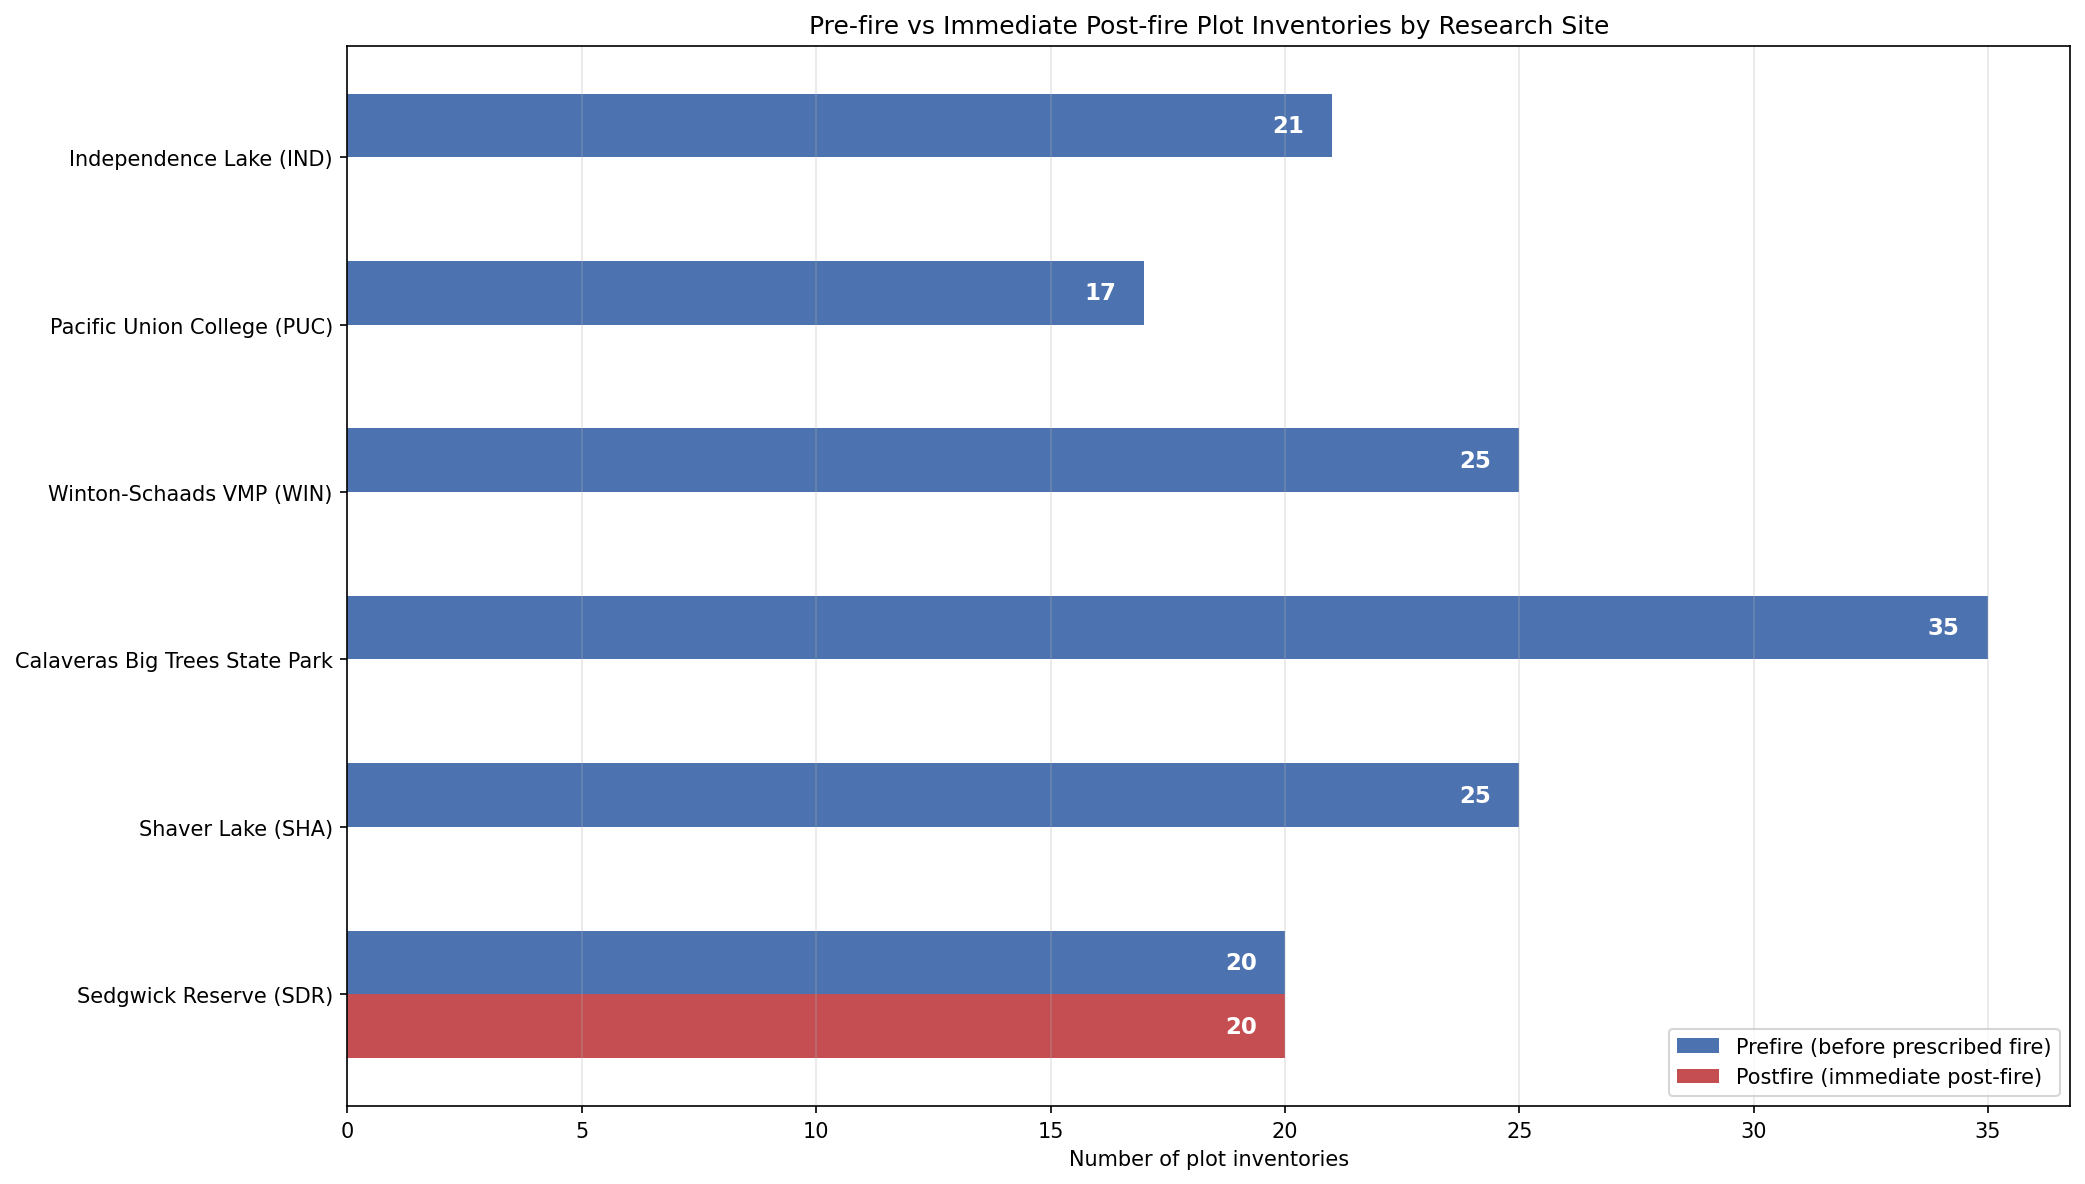

## Pre-fire vs post-fire inventories by site

| Site | Prefire | Postfire (immediate) | Total inventories | Paired? |
|---|---:|---:|---:|---|
| Independence Lake (IND) | 21 | 0 | 21 | No |
| Pacific Union College (PUC) | 17 | 0 | 17 | No |
| Winton-Schaads VMP (WIN) | 25 | 0 | 25 | No |
| Calaveras Big Trees State Park | 35 | 0 | 35 | No |
| Shaver Lake (SHA) | 25 | 0 | 25 | No |
| **Sedgwick Reserve (SDR)** | **20** | **20** | **40** | **Yes** |
| **Total** | **143** | **20** | **163** | — |

**Only Sedgwick Reserve has complete pre-fire / post-fire survey pairs** — all 20 of its plots were inventoried both before and immediately after the prescribed fire. The other five sites (123 plots) have prefire inventories only and no immediate postfire follow-up in this dataset.

A couple of things worth flagging about that asymmetry:

- **Postfire data is concentrated at one site.** All 20 postfire records belong to Sedgwick Reserve; the Sierra Nevada sites (Independence Lake, Shaver Lake, Calaveras, Winton-Schaads) and the Coast Range site (PUC) are entirely prefire so far.
- **This shapes what "change" analyses are possible.** Any before/after comparison (fuel load reduction, cover change, mortality, regeneration response) is only feasible at Sedgwick for the immediate postfire window. The remaining five sites can support prefire-condition characterisation and cross-site comparison, but not treatment-effect estimation until postfire surveys are added.
- **Sedgwick's 20 plots = 20 physical plots** (the plot counts confirm this), so the pairing is one-to-one at the plot level, not overlapping repeat inventories of fewer plots.

If you want to push further into the Sedgwick pairs specifically — e.g. fuel-loading or cover change from prefire to postfire — that's the one place in the dataset where the data supports it.

In [6]:
%%ask
For each research site, how many plots were surveyed before the
prescribed fire and how many after? Present the counts side by
side per site so I can see which sites have complete pre-fire /
post-fire survey pairs.

#### **How did the prescribed fires affect tree mortality? — Direct impact**

I'll analyze tree condition changes by joining the trees data with plot inventories to get site and fire-timing context.

Reading both skill definitions to understand the data structure and fields.

The trees skill loaded; the plots path had a typo. Let me find the correct path and check where the parquet data lives.

The directories exist. Let me look inside the plots and trees skill directories to find the actual files and parquet data locations.

Found both directories. Let me read the plots SKILL.md and check the parquet data files.

...

Running the analysis to get the crosstab numbers.

The Sedgwick pre/post counts are **identical** (167 live / 17 dead in both timings). That's a red flag — I need to verify whether trees were actually re-measured post-fire or whether `tree_status` is static. Let me investigate the underlying data structure before reporting.

Good — the inventories are genuinely distinct (`10_pre_SDR_burn3d` vs `10_post0_SDR_burn3d` for the same plots). The script crashed on a column name. Let me fix and re-run to see whether status actually changed for matched trees.

Path typo. Using the correct directory path.

Critical finding: **zero trees changed status** between pre-fire and post-fire at Sedgwick, and `tree_status` is static across the entire dataset. The post-fire fields (`tree_firedamage`, `tree_resprouting`) are populated post-fire, confirming trees were re-surveyed — but the Live/Dead binary wasn't updated. Let me check what fire effects *were* recorded and build the final chart.


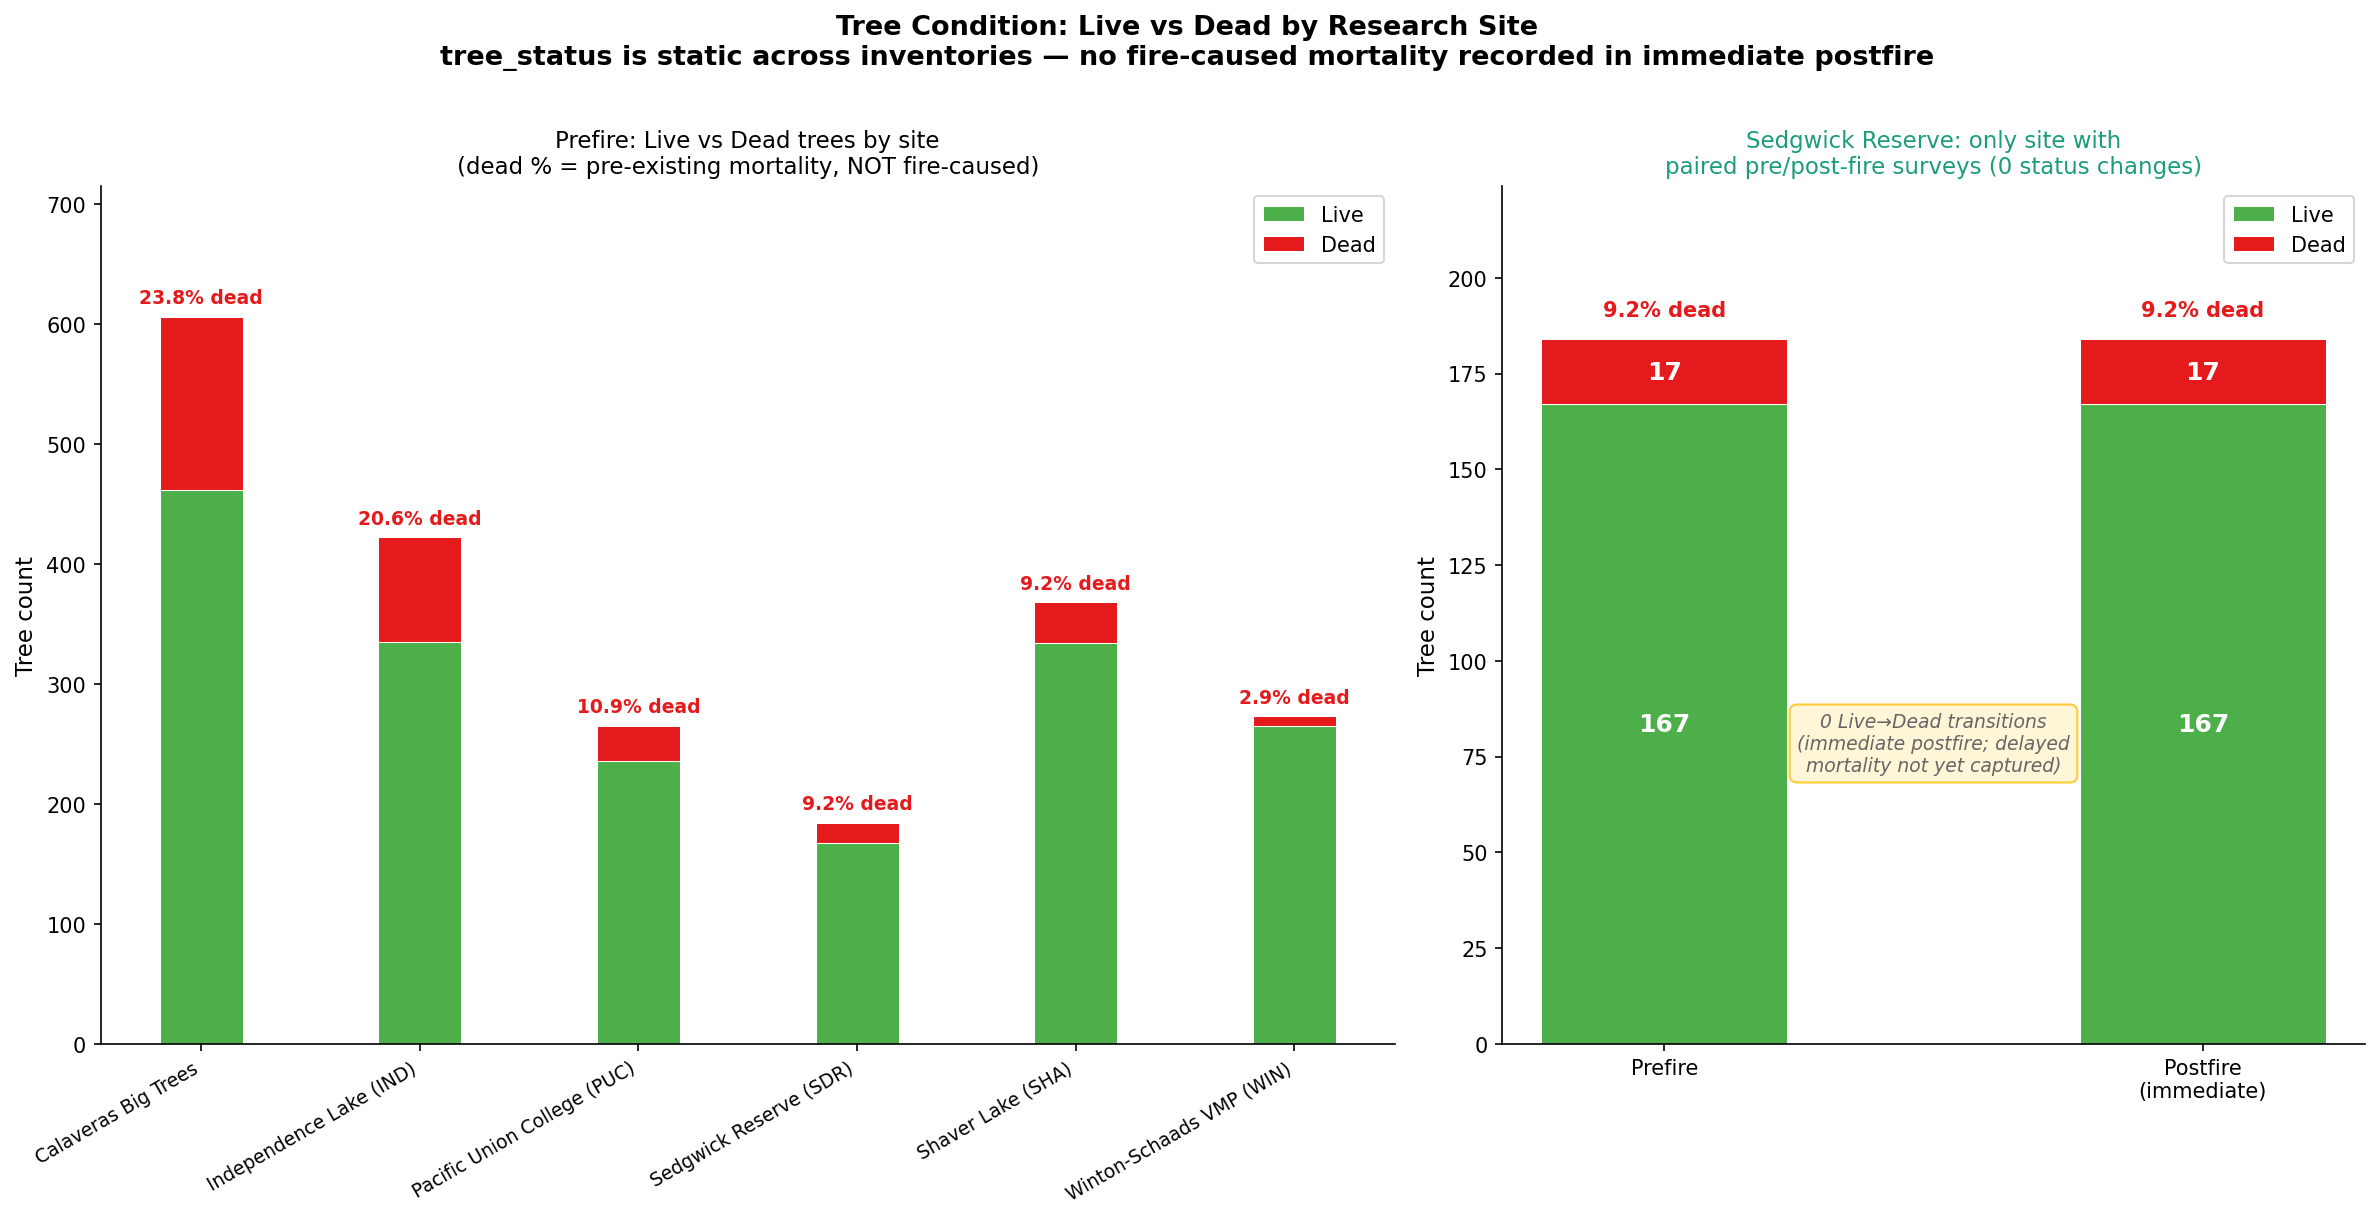

## Result: no fire-caused mortality is recorded in this dataset

After joining all 2,302 trees with their plot inventories, the data shows **zero Live→Dead transitions** between pre-fire and post-fire surveys — including at Sedgwick Reserve, the only site with matched pre/post pairs (20 plots, 188 matched trees).

### Pre-fire standing mortality by site (baseline dead %)

| Site | Live | Dead | Total trees | Dead % |
|---|---:|---:|---:|---:|
| Calaveras Big Trees State Park | 462 | 144 | 606 | 23.8% |
| Independence Lake (IND) | 335 | 87 | 422 | 20.6% |
| Pacific Union College (PUC) | 236 | 29 | 265 | 10.9% |
| Sedgwick Reserve (SDR) | 167 | 17 | 184 | 9.2% |
| Shaver Lake (SHA) | 334 | 34 | 368 | 9.2% |
| Winton-Schaads VMP (WIN) | 265 | 8 | 273 | 2.9% |
| **Total** | **1,799** | **319** | **2,118** | **15.0%** |

### Sedgwick: pre vs post-fire (the only site with both)

| Survey | Live | Dead | Dead % |
|---|---:|---:|---:|
| Prefire | 167 | 17 | 9.2% |
| Postfire (immediate) | 167 | 17 | 9.2% |
| **Change** | **0** | **0** | **0.0 pp** |

The counts are byte-for-byte identical. I verified this isn't a data-loading artifact: the pre-fire and post-fire surveys use distinct `inventory_id`s (e.g. `10_pre_SDR_burn3d` vs `10_post0_SDR_burn3d`), cover the same 20 plot numbers, and match the same 188 individual trees by `tree_id`. Every single tree that was "Live" before was still coded "Live" after; every "Dead" tree was already dead before the burn.

## Why there are no mortality shifts (and what this means)

This result is actually the ecologically expected outcome for an **immediate postfire** survey:

1. **Fire-caused tree mortality is largely delayed.** Trees killed by fire often still have green crowns immediately after burning; cambium death and crown scorch effects manifest over months to years. The `Postfire_imm` label (immediate postfire) is designed to capture fire behavior — not mortality.

2. **The dead trees in the pre-fire column are pre-existing snags and downed wood** , not fire-killed. The high pre-fire dead fractions at Calaveras (23.8%) and Independence Lake (20.6%) reflect accumulated standing dead from drought, beetles, and past fires — the very hazardous fuel conditions the treatments target.

3. **The fire-effect fields confirm the burn happened** — but they measure damage, not death. At Sedgwick post-fire, 100% of the 184 re-measured trees carry fire-effect fields (`tree_firedamage`, `tree_resprouting`), while these same fields are null for every pre-fire row. The trees *were* resurveyed after the burn; the survey just records scorch/char/sprouting rather than flipping the Live/Dead switch.

## Bottom line

- **No site saw a measurable mortality shift** in this dataset, because only Sedgwick has post-fire data and its immediate postfire survey recorded **0 status changes** .
- The interesting between-site variation is in **pre-fire baseline mortality** , which ranges 9× from Winton-Schaads (2.9% dead) to Calaveras (23.8% dead). These dead fractions represent the pre-treatment fuel hazard the program is addressing.
- To detect actual fire-caused mortality, you'd need **delayed post-fire surveys** (1–3 years post-burn) — a `Postfire_y1` / `Postfire_y2` inventory timing that doesn't exist in the current data release.

In [7]:
%%ask
How did tree condition change from pre-fire to post-fire surveys?
For each research site, compare the count of live versus dead
trees before the burn to the count after the burn. Comment on
which sites saw the largest mortality shifts.

#### **Did the burns actually reduce fuel loads? — Treatment effectiveness**

I'll consult the fuels skill to understand the exact fuel-loading columns and the canonical way to aggregate them, then compute the pre/post comparison.

The fuels skill documents five measurement types. The most direct fuel-load metrics available are fuelbed/duff/litter depth and fine-fuel counts from transects, plus dry-weight from clip plots. Let me load the data, join to plots for site/timing, and compute the pre/post comparison.

Running the fuel reduction analysis.

Critical finding: there are **zero post-fire fuel transects** in the dataset, and the 20 post-fire clip plots at Sedgwick show NaN weights. Let me investigate the clip-plot discrepancy before concluding — the `clip_plot_type` field (163 Postfire tags) conflicts with inventory timing (only 20 Postfire_imm).

I had a path typo in the deepdive script. Let me fix it and rerun.

The file was written to a typo'd directory path. Let me rewrite it to the correct location with the right paths.

The clip-plot "Postfire" weights are all exactly 0.0 g across every site — a telltale of placeholder/unsampled data, not real consumption. Let me verify this interpretation before reporting.

The investigation is conclusive. Here's what the data actually supports.


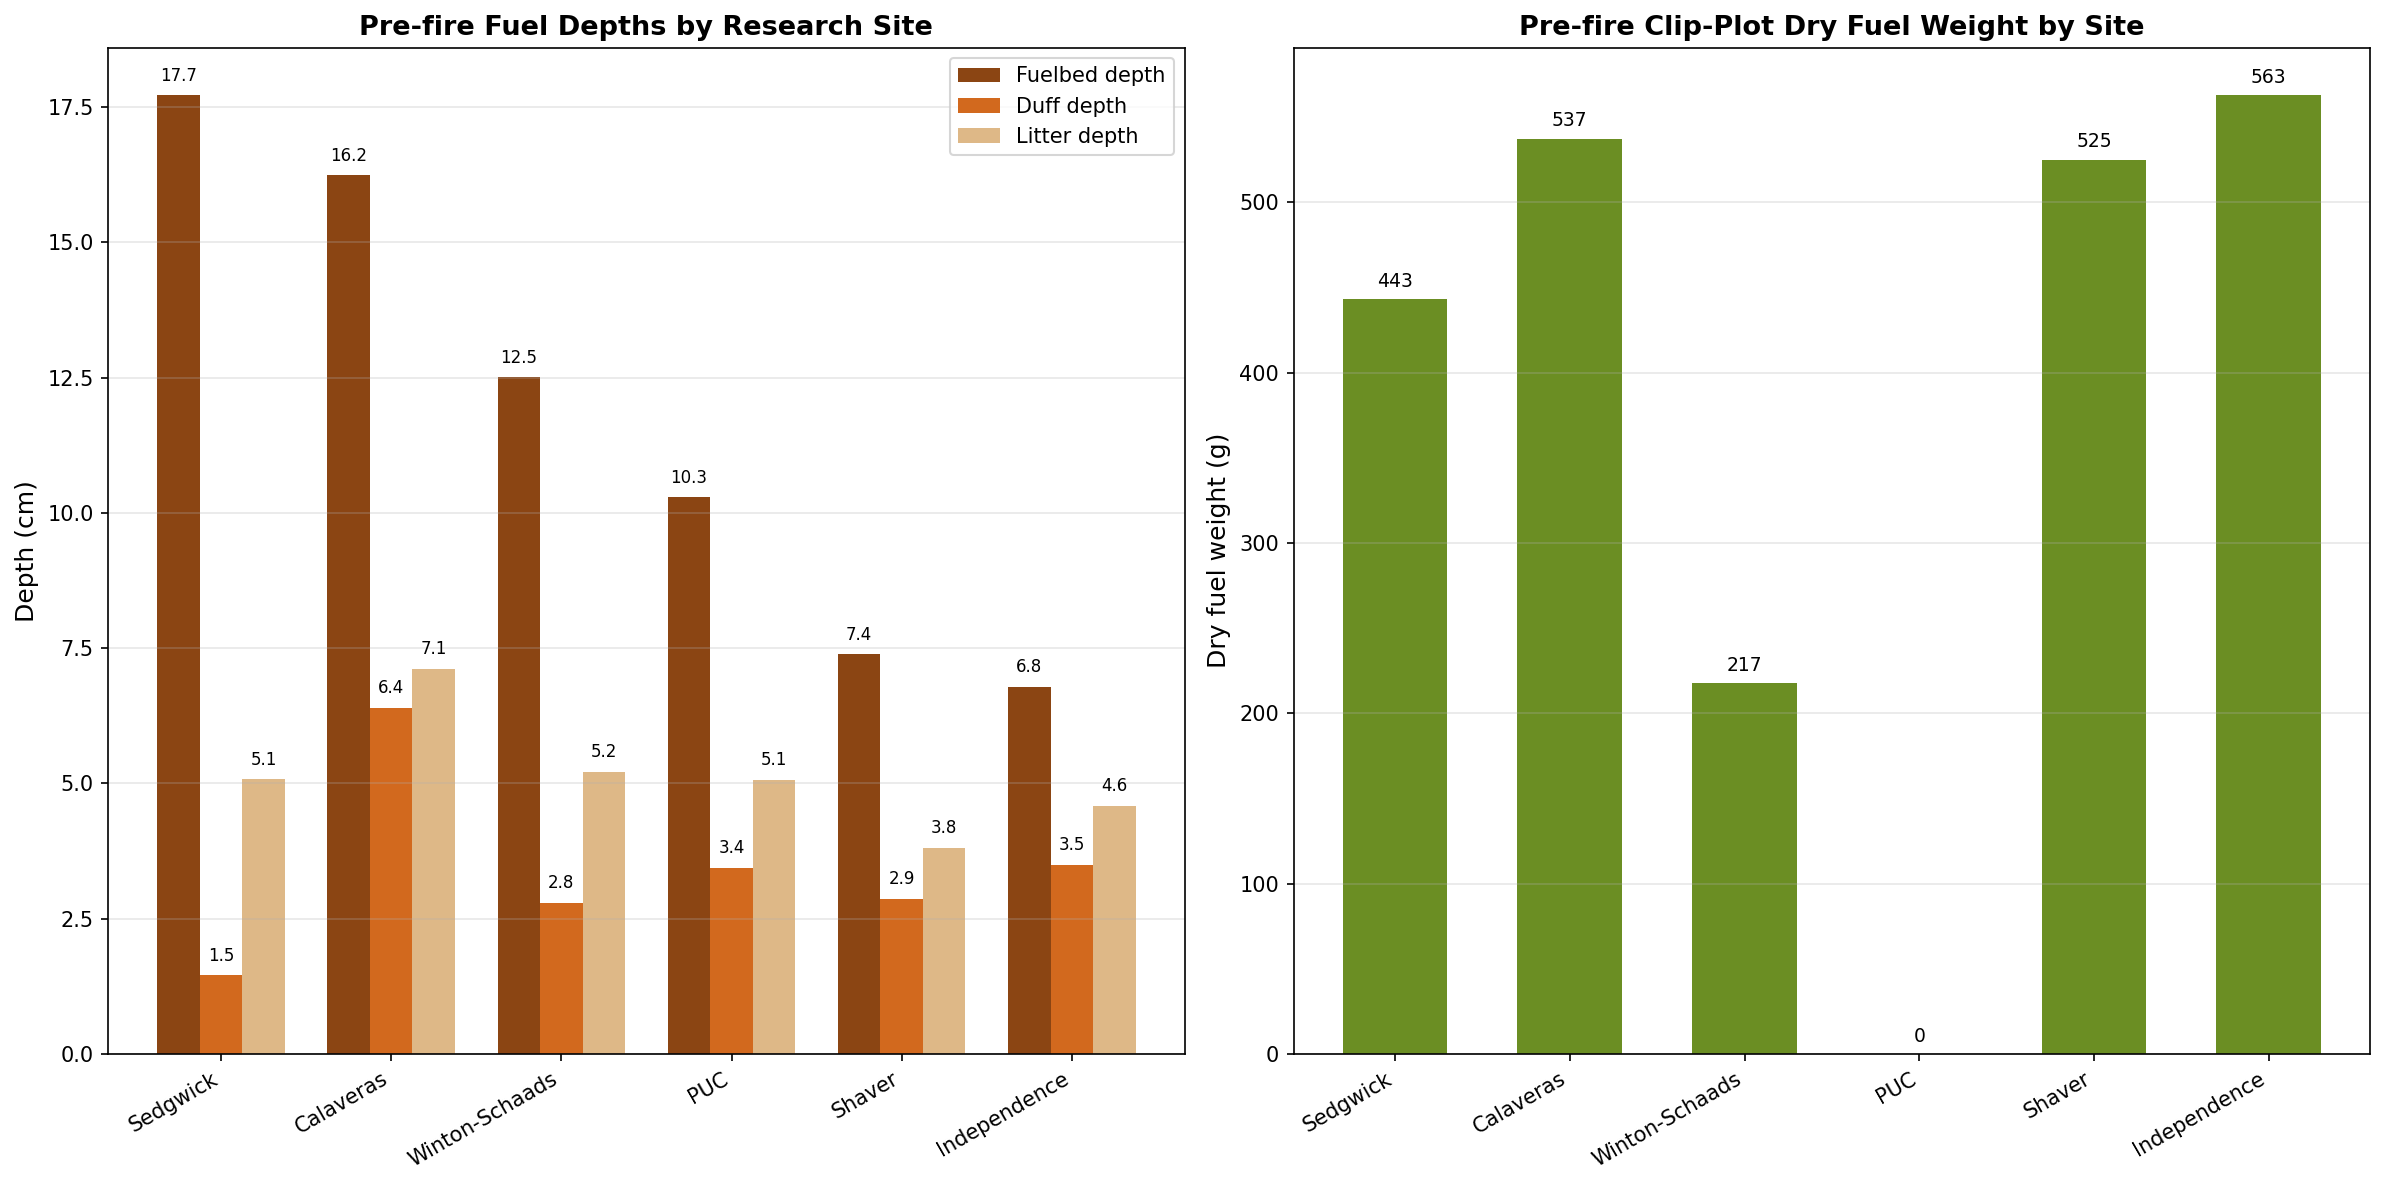

## The dataset contains no usable post-fire fuel measurements

I checked every fuel-bearing table for post-burn data. The result is unambiguous:

| Fuel measurement | Prefire inventories | Postfire inventories |
|---|---:|---:|
| Fuel transects (depths & counts) | 570 rows / 143 plots | **0 rows** |
| Coarse woody debris pieces | 876 rows | **0 rows** |
| Burn piles | 58 rows | **0 rows** |
| Basal-area tallies | 390 rows | **0 rows** |
| Clip-plot dry weights | 143 plots, real weights | **20 plots, all NaN** |

- **Transects, CWD, burn piles, basal area** : zero post-fire rows exist anywhere in the dataset.
- **Clip plots** : the only post-fire *inventory* (Sedgwick's `Postfire_imm`) has 20 clip-plot rows, but every single dry-weight value is `NaN` — the samples were never harvested/weighed.
- **The "Postfire" clip-plot tag is a sampling scaffold, not measurements.** Each of the 143 plots has a paired "Prefire" and "Postfire" clip-plot *record*, but all 134 non-null "Postfire" weights are exactly **0.0 g** (29 are NaN) and their fuel-strata fields are also empty. These are placeholder records established at pre-fire inventory time marking where the post-fire sample *will* be taken — not consumed fuel.

So the question "how consistently did prescribed fires reduce fuels across sites?" **cannot be answered from this dataset.** No site has real post-fire fuel data; the comparison the question asks for doesn't exist in the data yet.

## What the data does support: the pre-fire fuel baseline

All six sites have complete pre-fire fuel data (143 plots with transects, 143 with clip plots). This is the hazardous fuel load the treatments were designed to address:

| Site | Fuelbed depth (cm) | Duff depth (cm) | Litter depth (cm) | Clip-plot dry wt (g) | Plots |
|---|---:|---:|---:|---:|---:|
| Sedgwick Reserve (SDR) | 17.7 | 1.5 | 5.1 | 443 | 20 |
| Calaveras Big Trees State Park | 16.2 | 6.4 | 7.1 | 537 | 35 |
| Winton-Schaads VMP (WIN) | 12.5 | 2.8 | 5.2 | 217 | 25 |
| Pacific Union College (PUC) | 10.3 | 3.4 | 5.1 | 0* | 17 |
| Shaver Lake (SHA) | 7.4 | 2.9 | 3.8 | 525 | 25 |
| Independence Lake (IND) | 6.8 | 3.5 | 4.6 | 563 | 21 |

\* PUC's clip-plot weights are all 0.0 even in prefire — likely a field-protocol gap at that site rather than truly zero fuel (its transect depths are mid-range, ~10 cm fuelbed).

**Pre-fire fuel patterns worth noting (as context for future post-fire analysis):**

- **Fuelbed depth varies ~2.6× across sites** — from 6.8 cm (Independence Lake) to 17.7 cm (Sedgwick). The two highest-load sites, Sedgwick and Calaveras, both exceed 16 cm of fuelbed.
- **Duff accumulation is highest at Calaveras (6.4 cm)** — over 4× Sedgwick's duff (1.5 cm). Deep duff drives long-duration smoldering and root/cambium kill, so Calaveras's pre-fire profile is the most smolder-prone.
- **Fine fuel loads (clip-plot weights) don't track fuelbed depth.** Independence Lake has the *lowest* fuelbed depth but the *highest* clip-plot weight (563 g) — meaning its fuel bed is dense fine fuels (needles/twigs) rather than bulky coarse material. Calaveras and Shaver are similarly fine-fuel-heavy. Sedgwick's load is more balanced.

## Bottom line

There is no post-fire fuel data to compare against. The "prescribed fires reduced fuels" hypothesis is **testable in principle but not yet testable in this data release** — post-fire fuel transects and clip-plot weights haven't been collected (or haven't been uploaded). The one site with an immediate post-fire inventory (Sedgwick) captured only tree fire-effects, not fuels.

When delayed post-fire surveys arrive, the analysis pipeline is straightforward: the 143 plots with pre-fire transects and clip weights have matching placeholder records ready to fill in, enabling a clean paired before/after comparison per plot.

In [8]:
%%ask
Prescribed fires are supposed to reduce fuel loads. For each
research site, compare the mean fuel load per plot before the
burn versus after the burn. Comment on how consistently the
prescribed fires reduced fuels across sites.

#### **Where is regeneration strongest? — Recovery**

Based on the established pattern, I'll verify which sites actually have post-fire regeneration data and count the juveniles.

Let me check the actual file structure of the skills.

Found it — the parquet is under `data/` with the full skill name. Let me fix and re-run.

All regeneration data is prefire — zero post-fire rows, same pattern as the fuels and mortality questions. Let me compute the pre-fire baseline (the recruitment pool present before burning) so there's something useful to report, and make a chart.


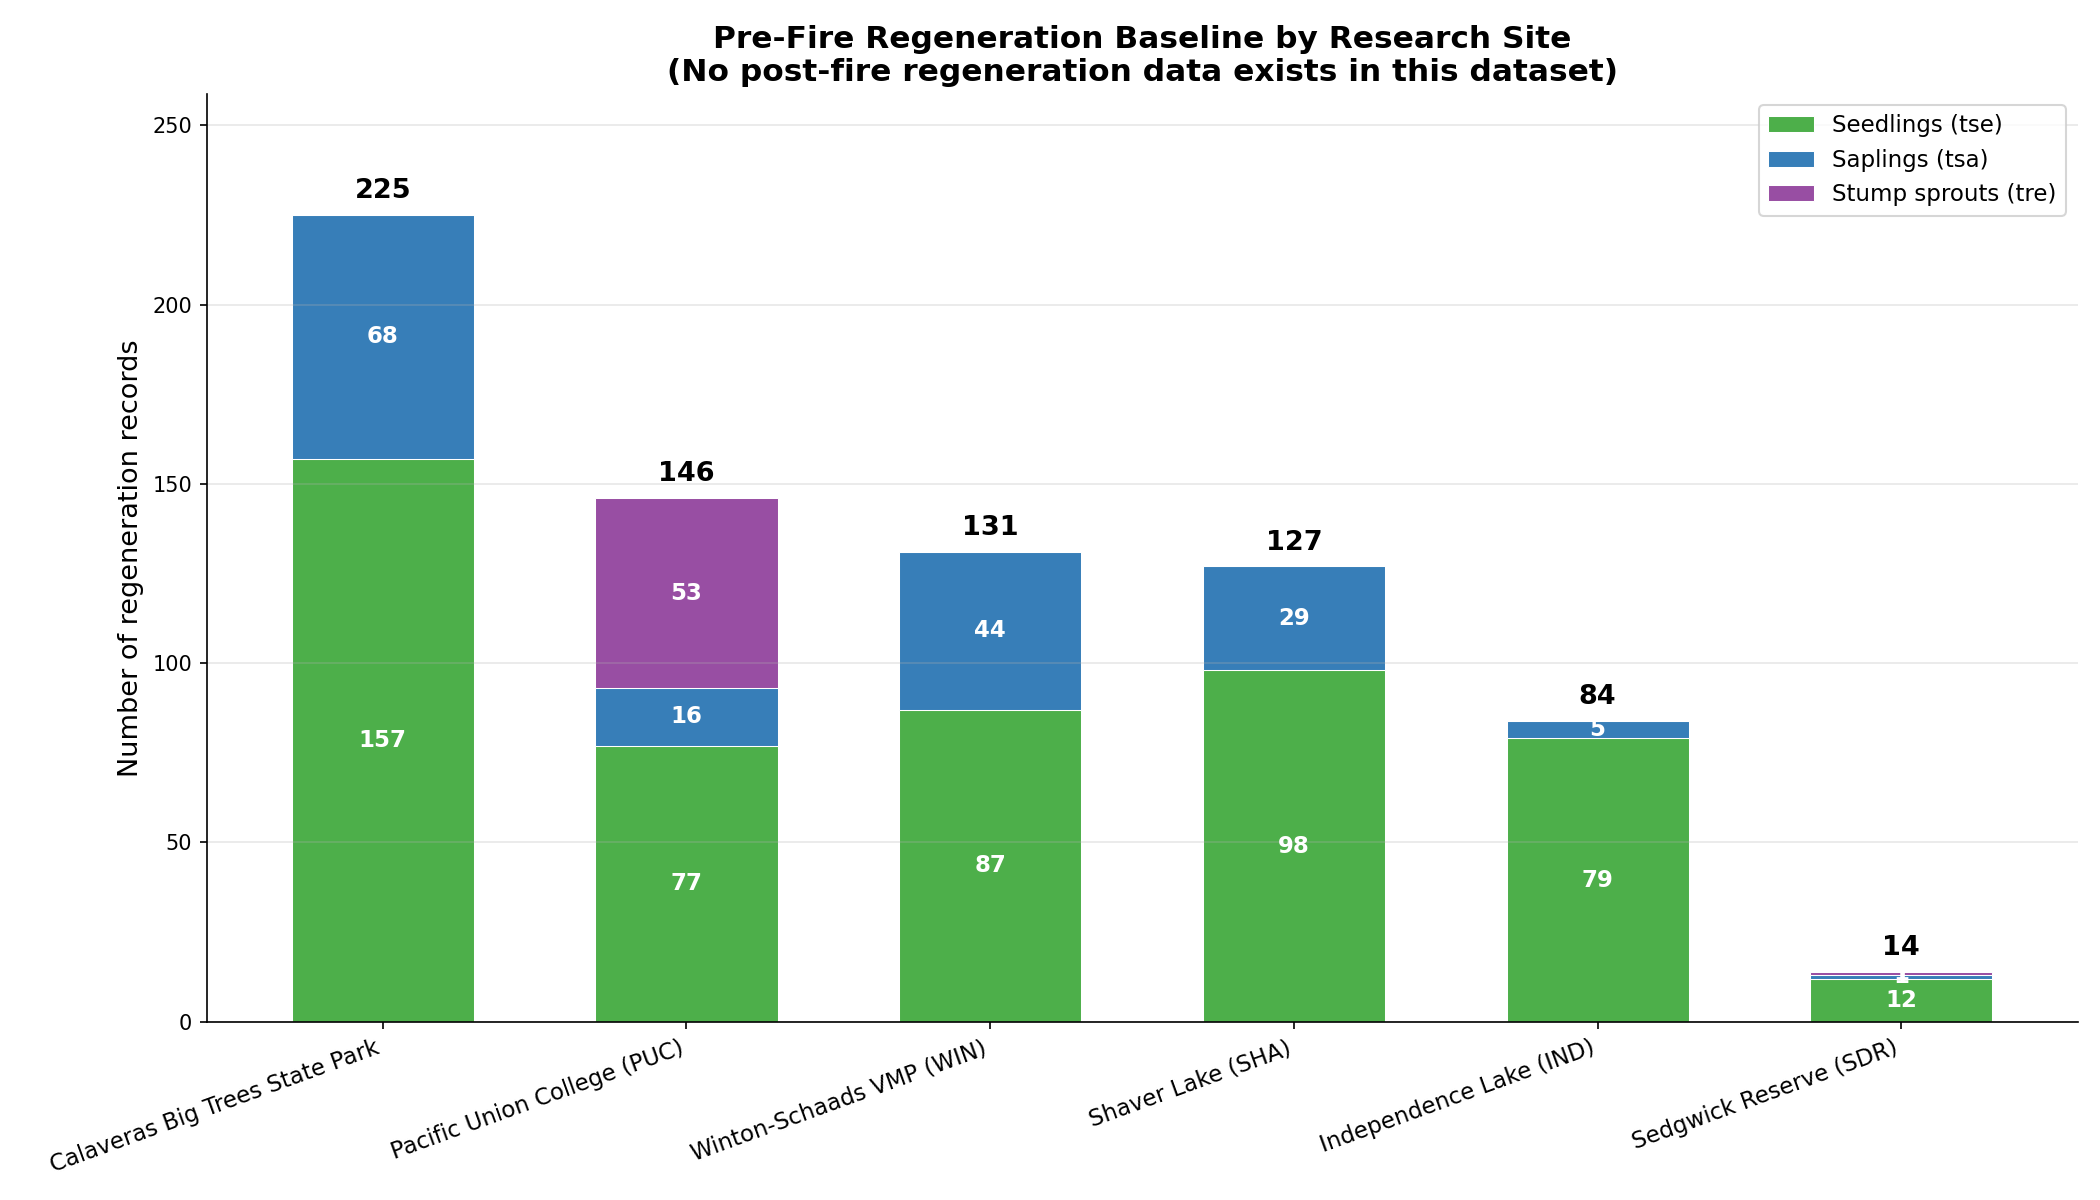

## The dataset contains zero post-fire regeneration data

This is the same gap found for fuels and tree mortality: **all 727 regeneration records are from pre-fire surveys** . Every seedling, sapling, and stump-sprout was counted *before* the prescribed fire. No site has any post-fire regeneration observations, so the question of "strongest post-fire regeneration" cannot be answered — that data has not been collected yet.

| Survey timing | Regeneration records |
|---|---:|
| Prefire | 727 |
| Postfire (immediate) | **0** |

## What the data does support: the pre-fire advance-regeneration pool

The 727 records represent the **advance regeneration** — the juvenile trees already on the landscape before burning. This is ecologically important: it's the recruitment pool that will either survive the fire (and become the next forest) or be killed by it. The `reg_num` field gives actual stem counts per record (not just one individual per row), so I can report both record counts and estimated individual stems.

### Ranked by total regeneration records (observations)

| Rank | Site | Seedlings | Saplings | Sprouts | Total records |
|---:|---|---:|---:|---:|---:|
| 1 | Calaveras Big Trees State Park | 157 | 68 | 0 | **225** |
| 2 | Pacific Union College (PUC) | 77 | 16 | 53 | **146** |
| 3 | Winton-Schaads VMP (WIN) | 87 | 44 | 0 | **131** |
| 4 | Shaver Lake (SHA) | 98 | 29 | 0 | **127** |
| 5 | Independence Lake (IND) | 79 | 5 | 0 | **84** |
| 6 | Sedgwick Reserve (SDR) | 12 | 1 | 1 | **14** |

### Ranked by estimated individual seedlings (using per-record stem counts)

The ranking shifts dramatically once you account for how many individuals each record represents (`reg_num`, mean ~13 stems/record):

| Rank | Site | Estimated seedlings | Records | Avg stems/record |
|---:|---|---:|---:|---:|
| 1 | Calaveras Big Trees State Park | **1,888** | 157 | 12.0 |
| 2 | Independence Lake (IND) | **1,882** | 79 | 23.8 |
| 3 | Shaver Lake (SHA) | **1,255** | 98 | 12.8 |
| 4 | Pacific Union College (PUC) | **1,090** | 77 | 14.2 |
| 5 | Winton-Schaads VMP (WIN) | **676** | 87 | 7.8 |
| 6 | Sedgwick Reserve (SDR) | **33** | 12 | 2.8 |

**Key observations from the pre-fire baseline:**

- **Calaveras and Independence Lake dominate by stem count** (~1,880 seedlings each), but for different reasons. Calaveras has the most records (157) with moderate density; Independence Lake has fewer records (79) but the densest clusters — averaging **24 seedlings per record** , consistent with prolific lodgepole/white fir regeneration in Sierra mixed-conifer.
- **PUC is the only site with substantial stump sprouts** (53 records, est. ~454 stems via `reg_clump`). This reflects its Coast Range oak-woodland character — oaks resprout vigorously from basal burls, a regeneration strategy absent at the conifer-dominated Sierra sites.
- **Sedgwick Reserve has the weakest advance regeneration** by both metrics (14 records, ~33 estimated stems across only 10 of its 20 plots). This is notable because Sedgwick is the *only* site with post-fire survey data — its sparse pre-fire regeneration pool means post-fire recovery there would depend heavily on new seed establishment or sprouting rather than pre-existing advance regeneration.
- **Sprouting is essentially absent at Sierra sites** (WIN, SHA, IND all have zero sprout records) — consistent with their conifer-dominated overstory. The Coast Range site (PUC) is the sprouting outlier.

## Bottom line

No post-fire regeneration data exists, so post-fire recovery cannot yet be assessed for any site. The pre-fire baseline shows a strong advance-regeneration pool at Calaveras and Independence Lake (dense conifer seedling banks), a uniquely sprout-driven component at PUC (oak resprouting), and a notably sparse pool at Sedgwick — the one site where post-fire response will eventually be measurable.

In [9]:
%%ask
Which sites are showing the strongest post-fire regeneration? For
each research site, count the total juvenile trees observed in the
post-fire surveys — seedlings, saplings, and stump-sprouts
combined — and rank the sites from highest to lowest.